# Feasibility of True Muonium Photoproduction

## Imports and Definitions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.constants import physical_constants

from importlib import reload
import helperFunctions as hf

In [2]:
# muon mass in [MeV]
muonMass_MeV = physical_constants['muon mass energy equivalent in MeV'][0]

# electron mass in [MeV]
electronMass_MeV = physical_constants['electron mass energy equivalent in MeV'][0]

# speed of light in vacuum in [m/s]
clight = physical_constants['speed of light in vacuum'][0]

## Parameters

In [3]:
# number of simulated primary photons
NSimBkg = 4e13

# initial photon beam energy in [MeV]
photonEnergy = 300

# Lorentz factor of the TM atom
lorentzFactor = photonEnergy/(2*muonMass_MeV)

# relativistic velocity of the TM atom
relVel = np.sqrt(1 - 1/lorentzFactor**2)

# dissociation length of Pb in [mm]
dissociationLength = 0.00346823 # in [mm]

# target thickness in [mm]
targetThickness = 2 * dissociationLength

# proper lifetime of oTM in [s]
otmTau = 1.81e-12

# cross-section bias for µ+µ-
muonPairBias = 1e6

# ratio of cross sections for µ+µ- / TM
boundStateSuppression = 61310060

In [4]:
# minimal energy in [MeV]
E_th_min = lorentzFactor * (muonMass_MeV - relVel*np.sqrt(muonMass_MeV**2 - electronMass_MeV**2))
E_th_max = lorentzFactor * (muonMass_MeV + relVel*np.sqrt(muonMass_MeV**2 - electronMass_MeV**2))
print(f'E in [{E_th_min:.1f}, {E_th_max:.1f}] MeV')

# maximal longitudinal position in [mm]
z_th_min = -500
z_th_max = 1000
print(f'z in [{z_th_min:.0f}, {z_th_max:.0f}] mm')

E in [43.5, 256.5] MeV
z in [-500, 1000] mm


## Event Preselection

In [5]:
tm = pd.read_pickle('data/tm.xz')
eleBG = pd.read_pickle('data/eleBG.xz')
posBG = pd.read_pickle('data/posBG.xz')

print(f'{len(tm)} true muonium events')
print(f'{len(eleBG)} electron events')
print(f'{len(posBG)} positron events')

55797 true muonium events
220469 electron events
200063 positron events


### Background

In [6]:
eleBG['ptot'] = np.sqrt(eleBG.px**2 + eleBG.py**2 + eleBG.pz**2)
eleBG['Etot'] = np.sqrt(eleBG.ptot**2 + electronMass_MeV**2)
eleBG['maskE'] = (eleBG.Etot>E_th_min) & (eleBG.Etot<E_th_max)
eleBG['maskZ'] = (eleBG.z>z_th_min) & (eleBG.z<z_th_max)

posBG['ptot'] = np.sqrt(posBG.px**2 + posBG.py**2 + posBG.pz**2)
posBG['Etot'] = np.sqrt(posBG.ptot**2 + electronMass_MeV**2)
posBG['maskE'] = (posBG.Etot>E_th_min) & (posBG.Etot<E_th_max)
posBG['maskZ'] = (posBG.z>z_th_min) & (posBG.z<z_th_max)

In [7]:
# combinatorial background
alphaBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='alpha')
ptBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='pt')
mInvBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='mInv')
dPhiBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='dPhi')
dcaBG = hf.combinatorialAnalysis(eleBG[eleBG.maskE & eleBG.maskZ], posBG[posBG.maskE & posBG.maskZ], which='dca')

print(f'{len(alphaBG.flatten())} background events')

780640 background events


### Signal

In [8]:
# create a mask to select events
mask = (tm.pz>0) & (tm.z<targetThickness)
tm = tm[mask]

# calculate the total momentum of the TM in [MeV]
tm['pt'] = np.sqrt(tm.px**2 + tm.py**2)
tm['ptot'] = np.sqrt(tm.px**2 + tm.py**2 + tm.pz**2)

tm['Etot'] = np.sqrt(tm.ptot**2 + (2*muonMass_MeV)**2)

# opening angle from TM momenta in [rad]
tm['theta'] = np.arccos(tm.pz / tm.ptot)

# TM path length in target in [mm]
tm['lTarget'] = (targetThickness-tm.z) / np.cos(tm.theta)

# dissociation probability
tm['pDiss'] = 1 - np.exp(-tm.lTarget/dissociationLength)

# sample the escaping of the TM
tm['escape'] = tm.pDiss < np.random.uniform(size=len(tm))

# beta factor of the TM atom
tm['beta'] = tm.ptot / tm.Etot

# gamma factor of the TM atom
tm['gamma'] = tm.Etot / (2*muonMass_MeV)

# decay length in [mm]
tm['decL'] = 1e3 * tm.gamma * tm.beta * clight * otmTau

# decay vertex magnitude in [mm]
tm['decV'] = np.array([np.random.exponential(dl) for dl in tm.decL])

# decay vertex coordinates in [mm]
tm['decVx'] = tm.x + (tm.decV * (tm.px/tm.ptot))
tm['decVy'] = tm.y + (tm.decV * (tm.py/tm.ptot))
tm['decVz'] = tm.z + (tm.decV * (tm.pz/tm.ptot))

In [9]:
# sample the TM decay, this gives the columns [Etot, px, py, pz]
ele, pos = hf.tmDecay(tm)

ele['pt'] = np.sqrt(ele.px**2 + ele.py**2)
ele['ptot'] = np.sqrt(ele.px**2 + ele.py**2 + ele.pz**2)

pos['pt'] = np.sqrt(pos.px**2 + pos.py**2)
pos['ptot'] = np.sqrt(pos.px**2 + pos.py**2 + pos.pz**2)

# polar angles with respect to z-axis
ele['theta'] = np.arccos(ele.pz / ele.ptot)
pos['theta'] = np.arccos(pos.pz / pos.ptot)

# azimuthal angle (with respect to the x-axis)
ele['phi'] = np.arctan2(ele['py'], ele['px'])
pos['phi'] = np.arctan2(pos['py'], pos['px'])

In [10]:
# inner radius of the detector in [mm]
detectorRadius = 150

# calculate the hit positions in [mm]
ele['hitX'], ele['hitY'], ele['hitZ'] = hf.forward_intersection(tm, ele, detectorRadius).T
pos['hitX'], pos['hitY'], pos['hitZ'] = hf.forward_intersection(tm, pos, detectorRadius).T

# mask for energy threshold
ele['maskE'] = (ele.Etot>E_th_min) & (ele.Etot<E_th_max)
pos['maskE'] = (pos.Etot>E_th_min) & (pos.Etot<E_th_max)

# mask for longitudinal position cut
ele['maskZ'] = (ele.hitZ>z_th_min) & (ele.hitZ<z_th_max)
pos['maskZ'] = (pos.hitZ>z_th_min) & (pos.hitZ<z_th_max)

In [11]:
# create the dataframe for the pairs
# corresponds mostly to the TM dataframe
pair = pd.DataFrame()

# calculate the signal pair momenta in [MeV]
pair['px'] = ele.px + pos.px
pair['py'] = ele.py + pos.py
pair['pz'] = ele.pz + pos.pz
pair['pt'] = np.sqrt(pair.px**2 + pair.py**2)

# calculate the opening angle of the signal pairs in [rad]
pair['alpha'] = np.arccos((pos.px*ele.px + pos.py*ele.py + pos.pz*ele.pz) / (pos.ptot*ele.ptot))

# calculate the azimuthal angle difference of the signal pairs in [rad]
pair['dPhi'] = abs(ele.phi - pos.phi)

# calculate the invariant mass of the signal pairs in [MeV]
pair['mInv'] = np.sqrt((pos.Etot+ele.Etot)**2 - ((pos.px + ele.px)**2 + (pos.py + ele.py)**2 + (pos.pz + ele.pz)**2))

In [12]:
ele['ux'] = ele.px / ele.ptot
ele['uy'] = ele.py / ele.ptot
ele['uz'] = ele.pz / ele.ptot

pos['ux'] = pos.px / pos.ptot
pos['uy'] = pos.py / pos.ptot
pos['uz'] = pos.pz / pos.ptot

# cross product: u_pos x u_ele
pair['cx'] = pos.uy * ele.uz - pos.uz * ele.uy
pair['cy'] = pos.uz * ele.ux - pos.ux * ele.uz
pair['cz'] = pos.ux * ele.uy - pos.uy * ele.ux
pair['crossNorm'] = np.sqrt(pair.cx**2 + pair.cy**2 + pair.cz**2)

# displacement between hit points
pair['dx'] = ele.hitX - pos.hitX
pair['dy'] = ele.hitY - pos.hitY
pair['dz'] = ele.hitZ - pos.hitZ

eps = 1e-12
pair['dca'] = np.where(pair.crossNorm > eps, np.abs(pair.dx*pair.cx + pair.dy*pair.cy + pair.dz*pair.cz) / pair.crossNorm, np.nan)

### Results

In [13]:
# photon flux on target [1/s] 
photonFlux = 1e15

# number of simulated photons (nSim x nEvents x bias)
NSigSim = 1e1 * 1e9 * 1e6

# number of muon pairs in detector acceptance
nPairs = np.sum(tm.escape & ele.maskZ&ele.maskE & pos.maskZ&pos.maskE)

print('signal events:')
print(f'{nPairs:.2e} muon pair / {NSigSim:.0e} photons')
print(f'{nPairs / boundStateSuppression:.2e} TM atoms / {NSigSim:.0e} photons')

print('\nsignal requirements:')
print(f'{1 / (nPairs / boundStateSuppression / NSigSim):.2e} photons / TM')
print(f'{1 / (photonFlux * nPairs / boundStateSuppression / NSigSim / 1e7):.2e} BX / TM')

print('\nsignal rates:')
print(f'{nPairs / boundStateSuppression / NSigSim:.2e} TM / photon')
print(f'{photonFlux * nPairs / boundStateSuppression / NSigSim:.2e} TM / s')
print(f'{photonFlux * nPairs / boundStateSuppression / NSigSim / 1e7:.2e} TM / BX')
print(f'{3600 * 24 * photonFlux * nPairs / boundStateSuppression / NSigSim:.2e} TM / d')

signal events:
2.05e+04 muon pair / 1e+16 photons
3.35e-04 TM atoms / 1e+16 photons

signal requirements:
2.99e+19 photons / TM
2.99e+11 BX / TM

signal rates:
3.35e-20 TM / photon
3.35e-05 TM / s
3.35e-12 TM / BX
2.89e+00 TM / d


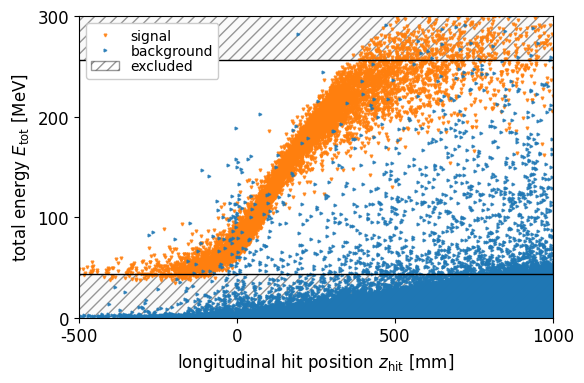

In [14]:
with plt.rc_context(hf.regu):
    
    fig, ax = plt.subplots()
    
    ax.plot(ele[::10].hitZ, ele[::10].Etot, 'C1v', ms=2, alpha=0.8, label='signal')
    ax.plot(pos[::10].hitZ, pos[::10].Etot, 'C1v', ms=2, alpha=0.8)
    
    ax.plot(eleBG.z, eleBG.Etot, 'C0>', ms=2, alpha=0.8, label='background')
    ax.plot(posBG.z, posBG.Etot, 'C0>', ms=2, alpha=0.8)

    xtick = [-500, 0, 500, 1000]
    ytick = [0, 100, 200, 300]
    ax.set(xlim=(-500,1000), ylim=(0,photonEnergy), xticks=xtick, xticklabels=xtick, yticks=ytick, yticklabels=ytick)
    
    hf.add_hatched_exclusion(ax, x0=z_th_min, x1=z_th_max, y0=E_th_min, y1=E_th_max, hatch='///', label='excluded')
    
    ax.legend(loc='upper left')
    ax.set(xlabel=r'longitudinal hit position $z_\text{hit}$ [mm]', ylabel=r'total energy $E_\text{tot}$ [MeV]')

    fig.tight_layout()
    fig.savefig('plots/eventPreselection.png', dpi=300)
    fig.savefig('plots/eventPreselection.pdf')

    plt.show()

## Background Rejection

In [15]:
# number of e-/e+ after preselection
# slighly higher than in binned data
Ne = 1852329
Np = 1644504

print(f'Ne = {Ne}')
print(f'Np = {Np}')
print()
print(f'{Ne/4e13:.2e} e-/y')
print(f'{Np/4e13:.2e} e+/y')

Ne = 1852329
Np = 1644504

4.63e-08 e-/y
4.11e-08 e+/y


In [16]:
# load histogrammed data of signal and background
H4D_bkg = np.load('data/bkgH4D.npz')['H4D']
H4D_sig = np.load('data/sigH4D.npz')['H4D']

# load the binning of the histogrammed data
bins = np.load('data/bkgH4D.npz')
bins = [bins['alphaBins'], bins['dPhiBins'], bins['ptBins'], bins['mInvBins']]

In [17]:
# opening angle in [deg]
s0_low = 60; s0_high = 140
s0 = hf.bin_range(bins[0], low=s0_low, high=s0_high)

# azimuthal angle in [deg]
s1_low = 160; s1_high = 200
s1 = hf.bin_range(bins[1], low=s1_low, high=s1_high)

# transverse momentum in [MeV]
s2_low = 0; s2_high = 34
s2 = hf.bin_range(bins[2], low=s2_low, high=s2_high)

# invariant mass in [MeV]
s3_low = 190; s3_high = 230
s3 = hf.bin_range(bins[3], low=s3_low, high=s3_high)

ss = [s0,s1,s2,s3]

Hbkg = H4D_bkg[s0, s1, s2, s3]
Hsig = H4D_sig[s0, s1, s2, s3]

In [18]:
# true positive (signal that survives all cuts)
TP = Hsig.sum()

# false negative (rejected signal events)
FN = H4D_sig.sum() - TP

# accepted signal events / all signal events
sigEff = TP / (TP + FN)
print('SIGNAL')
print(f'signal efficiency:\t{sigEff:.2e}')

print('\nBACKGROUND')
print(f'simulated photons:\t{NSimBkg:.2e}')
print(f'simulated BG events:\t{Ne*Np:.2e}')

# false positive (background that survives all cuts)
FP = Hbkg.sum()
print(f'\nfalse positive:\t\t{FP:.2e}')

# true negative (rejected background events)
TN = Ne*Np - FP

# accepted background events / all background events
bkgEff = FP / (FP + TN)
print(f'background efficiency:\t{bkgEff:.2e}')
print(f'background rejection: \t{(1-bkgEff):.2e}')

if FP==0:
    print('\nno false positive from simulation!')
    print(f'upper limit on background efficiency: {3/TN:.1e} at 95% C.L.')

SIGNAL
signal efficiency:	9.44e-01

BACKGROUND
simulated photons:	4.00e+13
simulated BG events:	3.05e+12

false positive:		0.00e+00
background efficiency:	0.00e+00
background rejection: 	1.00e+00

no false positive from simulation!
upper limit on background efficiency: 9.8e-13 at 95% C.L.


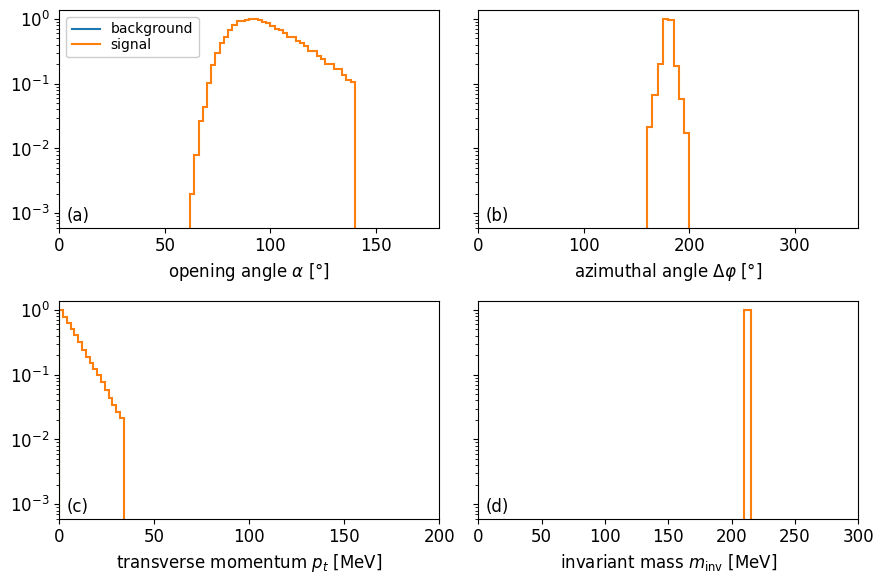

In [19]:
xlabels = [r'opening angle $\alpha$ [°]', 
           r'azimuthal angle $\Delta\varphi$ [°]', 
           r'transverse momentum $p_t$ [MeV]', 
           r'invariant mass $m_\text{inv}$ [MeV]']

subFigLabel = ['(a)', 
               '(b)', 
               '(c)', 
               '(d)']

with plt.rc_context(hf.regu):

    fig, ax = plt.subplots(2, 2, sharey=True, figsize=(9,6))
    ax = ax.flatten()
    
    for k in range(4):
        
        H_bkg_tmp = Hbkg.sum(axis=tuple(i for i in range(Hbkg.ndim) if i!=k))
        if H_bkg_tmp.max() != 0:
            H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()
        ax[k].stairs(H_bkg_tmp, bins[k][ss[k].start:ss[k].stop+1], color='C0', lw=1.5, label='background')
    
        H_sig_tmp = Hsig.sum(axis=tuple(i for i in range(Hsig.ndim) if i!=k))
        if H_sig_tmp.max() != 0:
            H_sig_tmp = H_sig_tmp / H_sig_tmp.max()
        ax[k].stairs(H_sig_tmp, bins[k][ss[k].start:ss[k].stop+1], color='C1', lw=1.5, label='signal')

        ax[k].text(0.02, 0.03, subFigLabel[k], transform=ax[k].transAxes)
        ax[k].set(xlabel=xlabels[k], xlim=(bins[k][0], bins[k][-1]), yscale='log', ylim=(6e-4, None))

    ax[0].legend()

    fig.tight_layout()
    
    plt.show()

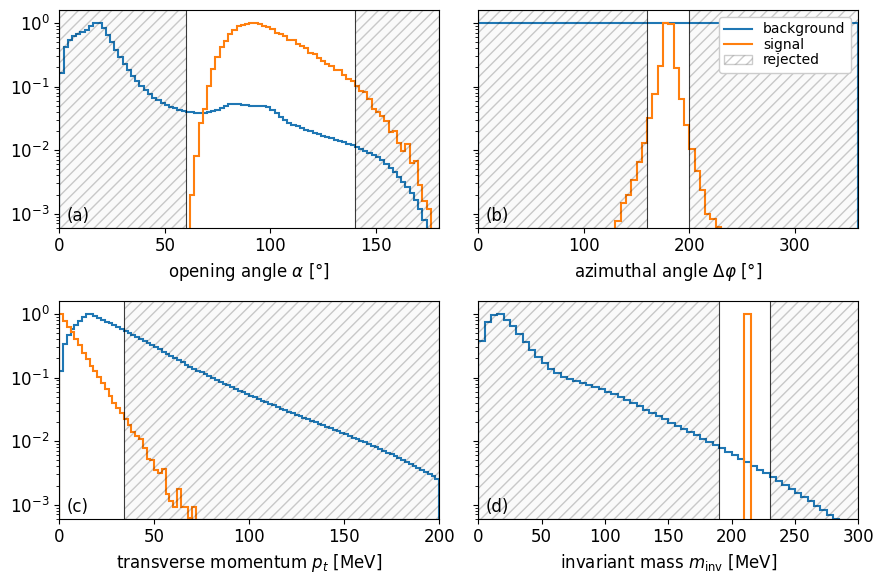

In [20]:
with plt.rc_context(hf.regu):

    fig, ax = plt.subplots(2, 2, sharey=True, figsize=(9,6))
    ax = ax.flatten()
    
    for k in range(4):
        
        H_bkg_tmp = H4D_bkg.sum(axis=tuple(i for i in range(H4D_bkg.ndim) if i!=k))
        if H_bkg_tmp.max() != 0:
            H_bkg_tmp = H_bkg_tmp / H_bkg_tmp.max()
        ax[k].stairs(H_bkg_tmp, bins[k], color='C0', lw=1.5, label='background')
    
        H_sig_tmp = H4D_sig.sum(axis=tuple(i for i in range(H4D_sig.ndim) if i!=k))
        if H_sig_tmp.max() != 0:
            H_sig_tmp = H_sig_tmp / H_sig_tmp.max()
        ax[k].stairs(H_sig_tmp, bins[k], color='C1', lw=1.5, label='signal')

        ax[k].text(0.02, 0.03, subFigLabel[k], transform=ax[k].transAxes)
        ax[k].set(xlabel=xlabels[k], xlim=(bins[k][0], bins[k][-1]), yscale='log', ylim=(6e-4, None))

    ax[0].axvline(s0_low, c='C5', ls='-', lw=0.5)
    ax[0].axvspan(bins[0][0], s0_low, color='C5', alpha=0.02, zorder=0)
    ax[0].axvspan(bins[0][0], s0_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[0].axvline(s0_high, c='C5', ls='-', lw=0.5)
    ax[0].axvspan(s0_high, bins[0][-1], color='C5', alpha=0.02, zorder=0)
    ax[0].axvspan(s0_high, bins[0][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)
    
    ax[1].axvline(s1_low, c='C5', ls='-', lw=0.5)
    ax[1].axvspan(bins[1][0], s1_low, color='C5', alpha=0.02, zorder=0)
    ax[1].axvspan(bins[1][0], s1_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[1].axvline(s1_high, c='C5', ls='-', lw=0.5)
    ax[1].axvspan(s1_high, bins[1][-1], color='C5', alpha=0.02, zorder=0)
    ax[1].axvspan(s1_high, bins[1][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)

    ax[2].axvline(s2_low, c='C5', ls='-', lw=0.5)
    ax[2].axvspan(bins[2][0], s2_low, color='C5', alpha=0.02, zorder=0)
    ax[2].axvspan(bins[2][0], s2_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[2].axvline(s2_high, c='C5', ls='-', lw=0.5)
    ax[2].axvspan(s2_high, bins[2][-1], color='C5', alpha=0.02, zorder=0)
    ax[2].axvspan(s2_high, bins[2][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')

    ax[3].axvline(s3_low, c='C5', ls='-', lw=0.5)
    ax[3].axvspan(bins[3][0], s3_low, color='C5', alpha=0.02, zorder=0)
    ax[3].axvspan(bins[3][0], s3_low, hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1, label='rejected')
    ax[3].axvline(s3_high, c='C5', ls='-', lw=0.5)
    ax[3].axvspan(s3_high, bins[3][-1], color='C5', alpha=0.02, zorder=0)
    ax[3].axvspan(s3_high, bins[3][-1], hatch='///', facecolor='none', edgecolor='C5', alpha=0.2, zorder=1)   

    ax[1].legend(loc='upper right')

    fig.tight_layout()
    fig.savefig('plots/eventDistributions.png', dpi=300)
    fig.savefig('plots/eventDistributions.pdf')
    
    plt.show()

## Lifetime